# Reading the data (with minimal preprocessing)...

In [1]:
import pandas as pd
import numpy as np
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from sklearn.model_selection import train_test_split


C:\Users\ronin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_full = pd.read_csv("data/Speed_Dating_Data.csv", encoding="latin1")
df_full.head()


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


The attributes I choose are attractiveness, fun, and shared interests. 
Since participants only talk for 4 minutes, it would make sense that a participant would mainly judge if he/she wants to see the other person based on "easily observable" traits, such as attractiveness and fun / "mutual vibe". 
Additionally, talking about commonality would most likely be a go-to topic since it's such a short conversation. 

In [3]:
# now selecting only the attr we chosen...
df = df_full[["dec", "attr", "fun", "shar"]].copy()
df.head()

,dec,attr,fun,shar
0,1,6.0,7.0,5.0
1,1,7.0,8.0,6.0
2,1,5.0,8.0,7.0
3,1,7.0,7.0,8.0
4,1,5.0,7.0,6.0


In [4]:
# looking at shape and if there's missing vals...
print(df.shape)
print(df.isna().sum())

(8378, 4)
dec        0
attr     202
fun      350
shar    1067
dtype: int64


In [5]:
# dropping data pts (rows) with missing vals...
df = df.dropna().copy()

print(df.shape)
df.head()

(7256, 4)


,dec,attr,fun,shar
0,1,6.0,7.0,5.0
1,1,7.0,8.0,6.0
2,1,5.0,8.0,7.0
3,1,7.0,7.0,8.0
4,1,5.0,7.0,6.0


In [6]:
# for binary classification val, we observe that there is no class imbalance... 
print(df["dec"].value_counts())
print(df["dec"].unique())

dec
0    4112
1    3144
Name: count, dtype: int64
[1 0]


# Splitting the data...

we only need train test split, no validation.

thus, we go with 80 20 train-test split

In [7]:
# fixed random seed for reproducibility...
np.random.seed(42)
idx = np.random.permutation(len(df))

split = int(0.8 * len(df))
train_idx = idx[:split]
test_idx = idx[split:]

X_train = df.iloc[train_idx].copy()
X_test = df.iloc[test_idx].copy()

print(X_train.shape)
print(X_test.shape)


(5804, 4)
(1452, 4)


In [8]:
X_train.head()

,dec,attr,fun,shar
3428,0,4.0,3.0,5.0
1949,1,9.0,7.0,7.0
4534,0,7.0,7.0,4.0
7340,0,2.0,10.0,4.0
7802,1,10.0,10.0,5.0


# Mean centering and scaling the data...

since we're not allowed to look at the testset in advance, we will meancenter and scale the testset wrt to the train set, since it comes from the same dataset

In [9]:
y_train = X_train["dec"].copy()
y_test = X_test["dec"].copy()

# dont standardise the target var...
attrs = ["attr", "fun", "shar"]

# compute mean and stdev of training set only...
train_mu = X_train[attrs].mean()
train_sigma = X_train[attrs].std()

X_train_standardised = (X_train[attrs] - train_mu) / train_sigma
X_test_standardised = (X_test[attrs] - train_mu) / train_sigma


# sanity checking...
print(X_train_standardised.head())
print()

# 10^-17 is effectively 0 due to floating point error...
print(X_train_standardised.mean())
print()

print(X_train_standardised.std())
print()

print(y_train.head())

          attr       fun      shar
3428 -1.113032 -1.712469 -0.215278
1949  1.439657  0.308098  0.710774
4534  0.418581  0.308098 -0.678304
7340 -2.134108  1.823523 -0.678304
7802  1.950195  1.823523 -0.215278

attr   -2.111796e-17
fun     1.392561e-16
shar   -1.273199e-16
dtype: float64

attr    1.0
fun     1.0
shar    1.0
dtype: float64

3428    0
1949    1
4534    0
7340    0
7802    1
Name: dec, dtype: int64


# Stan-based Bayesian regression

Our decision variable is binary, so hence, the appropiate likelihood is Bernoulli.



Particularly, our Bayesian linear regression would be of the form
$$
\mathrm{logit}(p_n) = \beta_0 
+ \beta_{\mathrm{attr}}x_{\mathrm{attr},n} 
+ \beta_{\mathrm{fun}}x_{\mathrm{fun},n} 
+ \beta_{\mathrm{shar}}x_{\mathrm{shar},n},
$$
where $\beta_0, \beta_{\mathrm{attr}}, \beta_{\mathrm{fun}}, \beta_{\mathrm{shar}} \sim \mathcal{N}(0, 2.5)$.

In [12]:
data_dict = {
    # train set...
    "N_train": len(y_train),
    "y_train": y_train.to_numpy().astype(int),
    "X_train": X_train_standardised.to_numpy(),

    # test set...
    "N_test": len(y_test),
    "X_test": X_test_standardised.to_numpy()
}

model = CmdStanModel(stan_file="models/q4.stan")
fit = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

18:48:15 - cmdstanpy - INFO - compiling stan file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw4\models\q4.stan to exe file C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw4\models\q4.exe
18:48:36 - cmdstanpy - INFO - compiled model executable: C:\Users\ronin\OneDrive\Pictures\cogmod\CogMod-HWs\hw4\models\q4.exe
18:48:37 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]





chain 1:   3%|▎         | 100/3500 [00:00<00:18, 182.36it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [00:01<00:14, 219.71it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:01<00:12, 243.15it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:02<00:11, 252.46it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:02<00:11, 261.98it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:02<00:10, 274.58it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:03<00:09, 289.53it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500 [00:03<


18:48:56 - cmdstanpy - INFO - CmdStan done processing.


In [13]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-2995.640000,0.020004,1.389110,1.200610,-2998.320000,-2995.330000,-2994.020000,5169.16,6286.07,86.8869,1.00117
beta_0,-0.421455,0.000327,0.032524,0.032869,-0.475265,-0.421617,-0.367242,9951.43,6756.13,167.2710,1.00019
beta[1],1.006100,0.000498,0.045679,0.046282,0.931249,1.005770,1.080630,8510.72,6974.66,143.0540,1.00079
beta[2],0.370519,0.000483,0.045609,0.045686,0.293561,0.370111,0.445261,8927.14,7429.97,150.0540,1.00026
beta[3],0.488746,0.000425,0.041186,0.041719,0.421526,0.488760,0.556449,9415.00,7620.20,158.2540,1.00034
...,...,...,...,...,...,...,...,...,...,...,...
p_hat[1448],0.543328,0.000136,0.013498,0.013478,0.521231,0.543185,0.565578,9856.80,7913.12,165.6800,1.00029
p_hat[1449],0.078978,0.000069,0.006287,0.006356,0.069065,0.078739,0.089626,8323.95,7089.44,139.9150,1.00030
p_hat[1450],0.670160,0.000118,0.012283,0.012301,0.649992,0.670265,0.690225,10925.30,8133.79,183.6400,1.00048
p_hat[1451],0.594484,0.000163,0.015975,0.015745,0.568060,0.594454,0.620851,9646.41,7695.28,162.1440,1.00034


it take several minute so no plot...

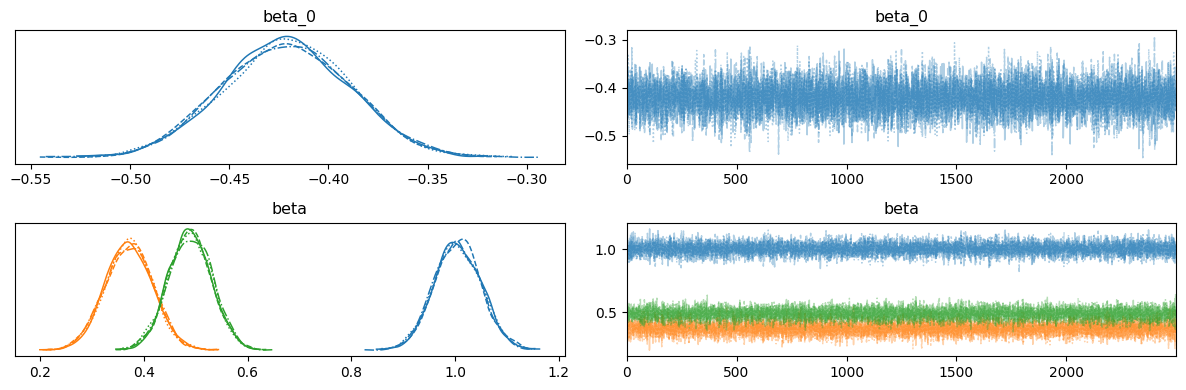

In [ ]:
# Traceplots and marginals - visual convergence checks
# axarr = az.plot_trace(fit)
# plt.tight_layout()

# Use of train test split...?

...it seems I had to read to the next question to understand the need for this split.
I made new files for this question but kept the previous result intact, because I thought it was a cool exploration regardless :\)\)

It is cool to see how we were able to obtain the test set accuracy in 2 different ways (with and without the use of generated parameters)

In [ ]:
# extracting the predicted probabilities for the test set from the fitted model...
p_hat_samples = fit.stan_variable("p_hat")

# calculating mean predicted probability...
p_bar = p_hat_samples.mean(axis=0)

# brier score (as taken from hw pdf)...
brier_score = ((p_bar - y_test.to_numpy())**2).mean()

# calculating accuracy on the test set...
predictions = (p_bar > 0.5).astype(int)
accuracy = (predictions == y_test.to_numpy()).mean()

print(f"Brier Score: {brier_score:.4f}")
print(f"Test Set Accuracy: {accuracy:.2%}")

Brier Score: 0.1684
Test Set Accuracy: 75.28%
